<a href="https://colab.research.google.com/github/abrar225/COVID-19-Data-Analysis/blob/main/this_is_my_project_complete_this_so_i_can_export_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COVID-19 Data Analysis, Forecasting, and Healthcare Preparedness (PRCP-1023)


In [ ]:
# Setup: Download and extract dataset
import os
import urllib.request
import zipfile

dataset_url = "https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/covid-19.zip"
zip_filename = "covid-19.zip"
data_dir = "covid_data"

if not os.path.exists(zip_filename):
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_filename)
    print("Download complete.")

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(data_dir)
    print("Files extracted successfully:")
    print(os.listdir(data_dir))

Download complete.
Files extracted successfully:
['dataset']


---

### Cell 3 [Code]

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

---

### Cell 4 [Code]

In [ ]:
# Task 1: Data Ingestion & Preprocessing
import os
import glob
import pandas as pd

# Locate standard JHU files dynamically inside the extracted directory
confirmed_path = glob.glob(f"{data_dir}/**/time_series_covid19_confirmed_global.csv", recursive=True)
deaths_path = glob.glob(f"{data_dir}/**/time_series_covid19_deaths_global.csv", recursive=True)

if not confirmed_path or not deaths_path:
    raise FileNotFoundError(f"Could not find time-series files inside '{data_dir}'.")

print(f"Loading cases from: {confirmed_path[0]}")
print(f"Loading deaths from: {deaths_path[0]}")

raw_cases = pd.read_csv(confirmed_path[0])
raw_deaths = pd.read_csv(deaths_path[0])

def clean_jhu_standard(df):
    # Group by Country/Region, dropping geographic coordinate columns
    grouped = df.drop(columns=['Lat', 'Long', 'Province/State'], errors='ignore').groupby('Country/Region').sum()

    # Transpose so dates become the DatetimeIndex and countries become columns
    ts_df = grouped.T
    ts_df.index = pd.to_datetime(ts_df.index)

    # Convert cumulative totals into daily new counts
    daily_df = ts_df.diff().fillna(0).clip(lower=0)
    return daily_df

df_cases = clean_jhu_standard(raw_cases)
df_deaths = clean_jhu_standard(raw_deaths)

print(f"Dataset covers: {df_cases.index.min().strftime('%Y-%m-%d')} to {df_cases.index.max().strftime('%Y-%m-%d')}")
print(f"Total Countries Tracked: {df_cases.shape[1]}")
print(f"Total Observations (Days): {df_cases.shape[0]}")

Loading cases from: covid_data/dataset/time_series_covid19_confirmed_global.csv
Loading deaths from: covid_data/dataset/time_series_covid19_deaths_global.csv
Dataset covers: 2020-01-22 to 2020-09-21
Total Countries Tracked: 188
Total Observations (Days): 244


---

### Cell 5 [Code]

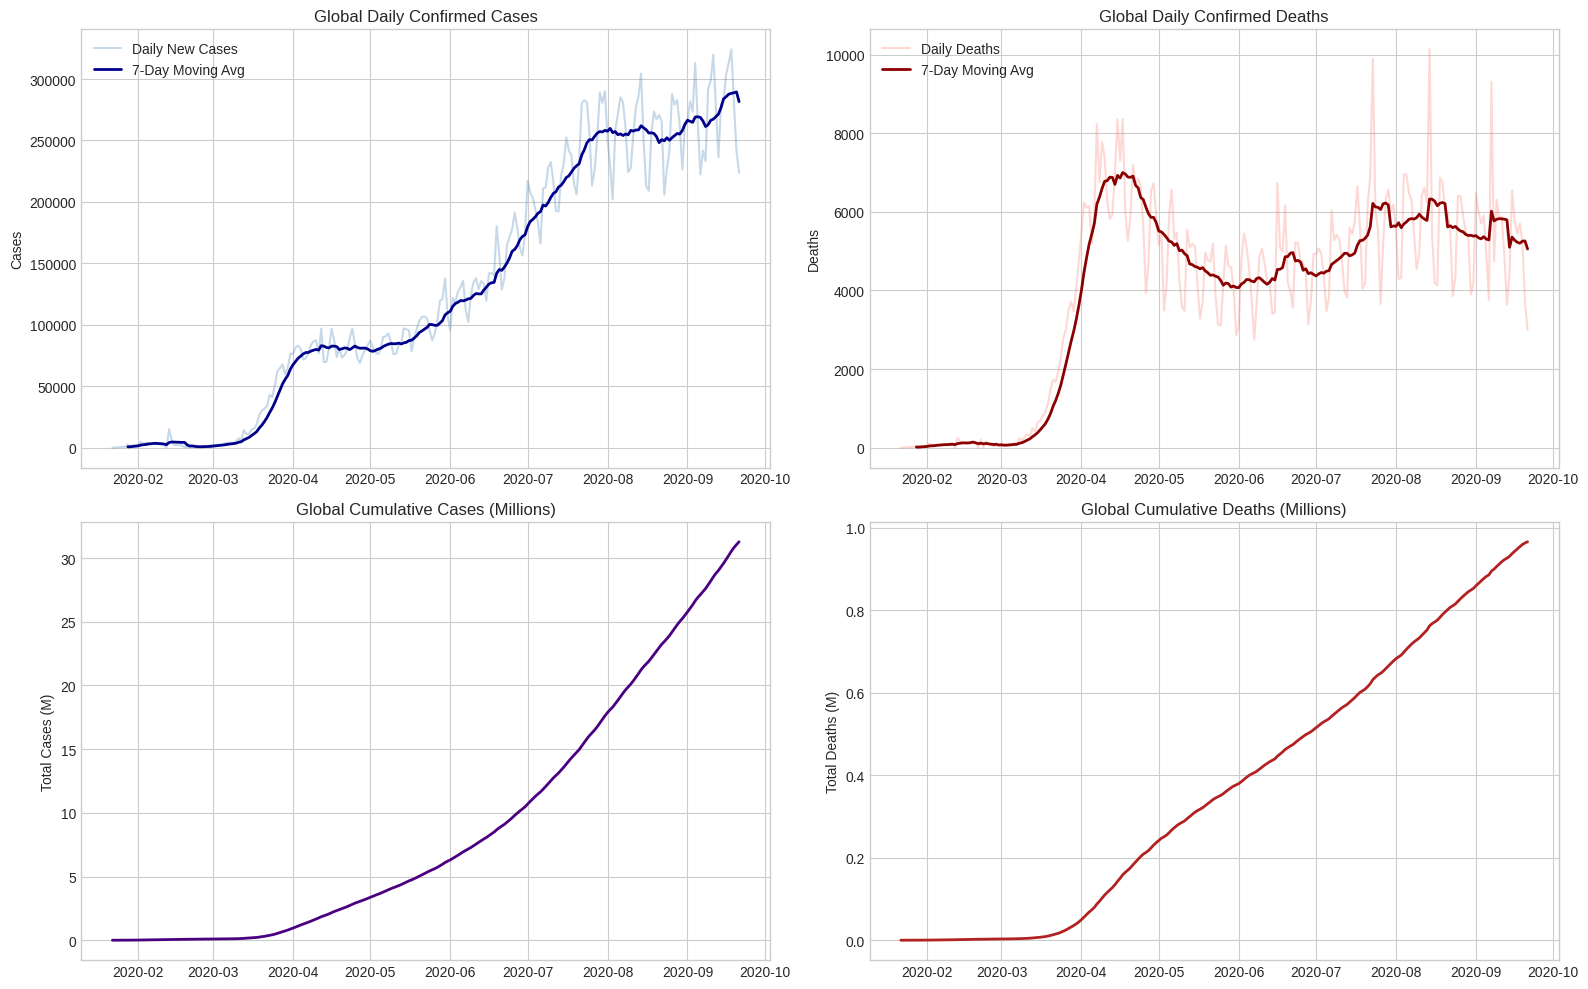

In [ ]:
# Task 1: Exploratory Data Analysis - Global Aggregates
global_daily_cases = df_cases.sum(axis=1)
global_daily_deaths = df_deaths.sum(axis=1)

global_summary = pd.DataFrame({
    'Daily_Cases': global_daily_cases,
    'Cases_7D_MA': global_daily_cases.rolling(7).mean(),
    'Daily_Deaths': global_daily_deaths,
    'Deaths_7D_MA': global_daily_deaths.rolling(7).mean(),
    'Cumulative_Cases': global_daily_cases.cumsum(),
    'Cumulative_Deaths': global_daily_deaths.cumsum()
})

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Daily Cases
axes[0, 0].plot(global_summary.index, global_summary['Daily_Cases'], color='steelblue', alpha=0.3, label='Daily New Cases')
axes[0, 0].plot(global_summary.index, global_summary['Cases_7D_MA'], color='darkblue', linewidth=2, label='7-Day Moving Avg')
axes[0, 0].set_title('Global Daily Confirmed Cases')
axes[0, 0].set_ylabel('Cases')
axes[0, 0].legend()

# Daily Deaths
axes[0, 1].plot(global_summary.index, global_summary['Daily_Deaths'], color='salmon', alpha=0.3, label='Daily Deaths')
axes[0, 1].plot(global_summary.index, global_summary['Deaths_7D_MA'], color='darkred', linewidth=2, label='7-Day Moving Avg')
axes[0, 1].set_title('Global Daily Confirmed Deaths')
axes[0, 1].set_ylabel('Deaths')
axes[0, 1].legend()

# Cumulative Cases
axes[1, 0].plot(global_summary.index, global_summary['Cumulative_Cases'] / 1e6, color='indigo', linewidth=2)
axes[1, 0].set_title('Global Cumulative Cases (Millions)')
axes[1, 0].set_ylabel('Total Cases (M)')

# Cumulative Deaths
axes[1, 1].plot(global_summary.index, global_summary['Cumulative_Deaths'] / 1e6, color='firebrick', linewidth=2)
axes[1, 1].set_title('Global Cumulative Deaths (Millions)')
axes[1, 1].set_ylabel('Total Deaths (M)')

plt.tight_layout()
plt.show()

---

### Cell 6 [Code]

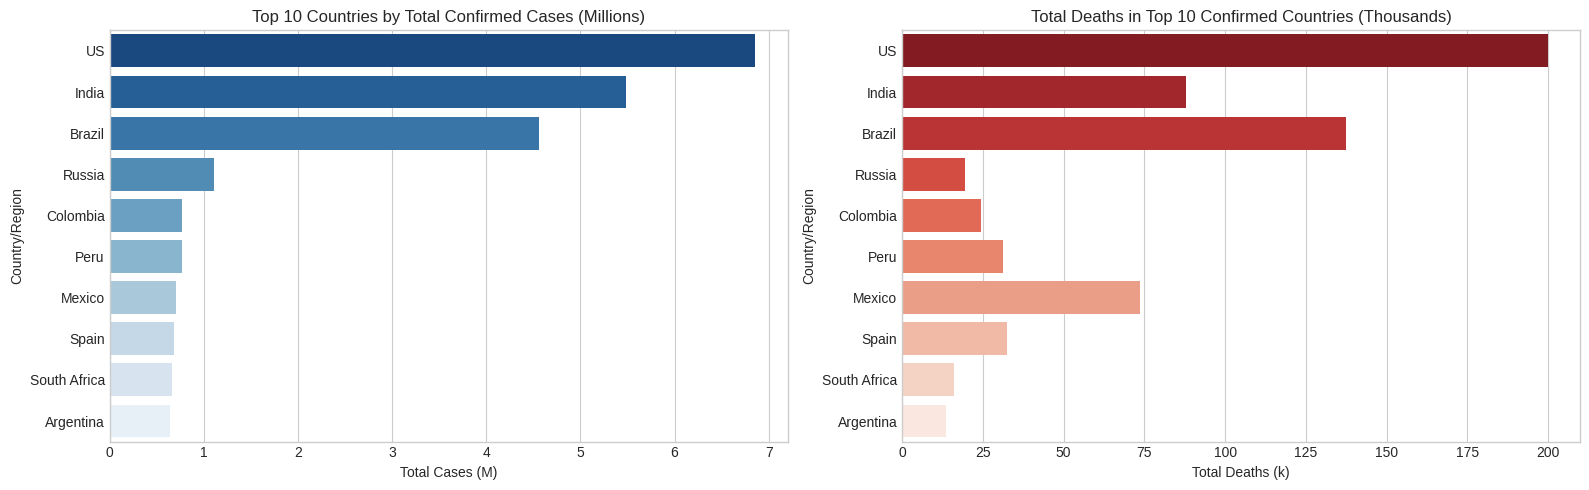

,Total_Cases,Total_Deaths,CFR_Percent
Country/Region,,,
US,6856883.0,199865.0,2.914808
India,5487580.0,87883.0,1.601489
Brazil,4558040.0,137272.0,3.011645
Russia,1105048.0,19420.0,1.757390
Colombia,770750.0,24401.0,3.165877
Peru,768895.0,31369.0,4.079751
Mexico,700580.0,73697.0,10.519427
Spain,681874.0,32583.0,4.778449
South Africa,661936.0,15992.0,2.415944


In [ ]:
# Task 1: Top 10 Impacted Countries Analysis
country_totals = pd.DataFrame({
    'Total_Cases': df_cases.sum(axis=0),
    'Total_Deaths': df_deaths.sum(axis=0)
})
country_totals['CFR_Percent'] = (country_totals['Total_Deaths'] / country_totals['Total_Cases']) * 100
top10_cases = country_totals.sort_values(by='Total_Cases', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=top10_cases['Total_Cases'] / 1e6, y=top10_cases.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Countries by Total Confirmed Cases (Millions)')
axes[0].set_xlabel('Total Cases (M)')

sns.barplot(x=top10_cases.loc[top10_cases.index, 'Total_Deaths'] / 1e3, y=top10_cases.index, ax=axes[1], palette='Reds_r')
axes[1].set_title('Total Deaths in Top 10 Confirmed Countries (Thousands)')
axes[1].set_xlabel('Total Deaths (k)')

plt.tight_layout()
plt.show()

display(top10_cases)

---

### Cell 7 [Code]

In [ ]:
# Task 2: Predictive Modeling Setup
# Target country: US
# Period definition: Last 60 days reserved for evaluation (test set)
COUNTRY = 'US'
TEST_DAYS = 60
FORECAST_DAYS = 30

# Using 7-day rolling average to reduce single-day reporting artifacts (weekend dips / Monday spikes)
ts_raw = df_cases[COUNTRY].astype(float)
ts_smooth = ts_raw.rolling(window=7, min_periods=1).mean()

# Feature Engineering for Supervised Models
df_model = pd.DataFrame({'actual_smooth': ts_smooth})
for lag in [1, 2, 3, 7, 14]:
    df_model[f'lag_{lag}'] = df_model['actual_smooth'].shift(lag)

df_model['rolling_mean_7'] = df_model['actual_smooth'].shift(1).rolling(7).mean()
df_model['rolling_std_7'] = df_model['actual_smooth'].shift(1).rolling(7).std()
df_model['day_of_week'] = df_model.index.dayofweek
df_model = df_model.dropna()

# Train/Test Split
feature_cols = [c for c in df_model.columns if c != 'actual_smooth']
X = df_model[feature_cols]
y = df_model['actual_smooth']

X_train, X_test = X.iloc[:-TEST_DAYS], X.iloc[-TEST_DAYS:]
y_train, y_test = y.iloc[:-TEST_DAYS], y.iloc[-TEST_DAYS:]

test_dates = y_test.index
print(f"Training Range: {y_train.index.min().strftime('%Y-%m-%d')} to {y_train.index.max().strftime('%Y-%m-%d')}")
print(f"Testing Range:  {y_test.index.min().strftime('%Y-%m-%d')} to {y_test.index.max().strftime('%Y-%m-%d')}")

Training Range: 2020-02-05 to 2020-07-23
Testing Range:  2020-07-24 to 2020-09-21


---

### Cell 8 [Code]

In [ ]:
# Task 2: Model Training & Evaluation

# 1. Linear Regression Baseline
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# 2. Random Forest Regressor
rf = RandomForestRegressor(n_estimators=150, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# 3. Time-Series Model: ARIMA (p=2, d=1, q=2)
# Trained strictly on univariate series up to train split
arima_train = ts_smooth.loc[y_train.index]
arima_model = ARIMA(arima_train, order=(2, 1, 2))
arima_fitted = arima_model.fit()
pred_arima = arima_fitted.forecast(steps=TEST_DAYS)
pred_arima.index = test_dates

# Performance Metrics Function
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

metrics = {
    'Linear Regression': evaluate(y_test, pred_lr),
    'Random Forest': evaluate(y_test, pred_rf),
    'ARIMA (2,1,2)': evaluate(y_test, pred_arima)
}

report_df = pd.DataFrame(metrics, index=['MAE', 'RMSE', 'R2 Score']).T
display(report_df)

,MAE,RMSE,R2 Score
Linear Regression,726.284109,867.685175,0.992357
Random Forest,7454.898881,8058.434449,0.340766
"ARIMA (2,1,2)",8472.199624,10270.381598,-0.070808


---

### Cell 9 [Code]

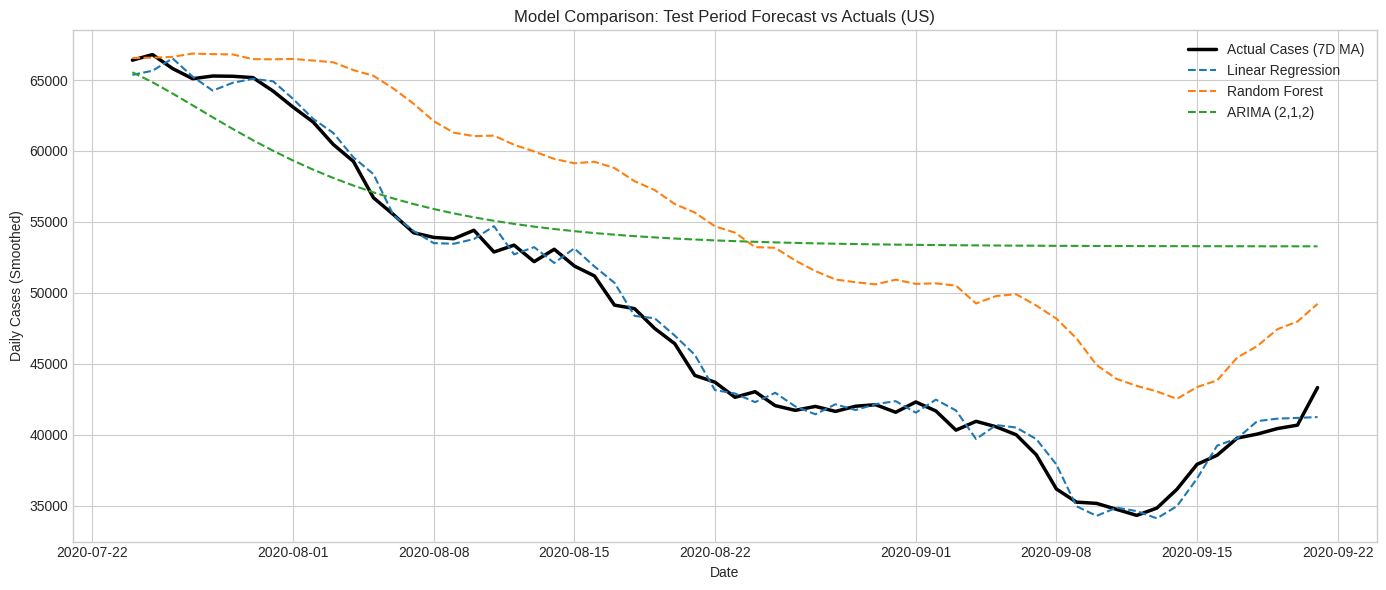

In [ ]:
# Task 2: Comparative Prediction Plots
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test, label='Actual Cases (7D MA)', color='black', linewidth=2.5)
plt.plot(test_dates, pred_lr, label='Linear Regression', linestyle='--', linewidth=1.5)
plt.plot(test_dates, pred_rf, label='Random Forest', linestyle='--', linewidth=1.5)
plt.plot(test_dates, pred_arima, label='ARIMA (2,1,2)', linestyle='--', linewidth=1.5)

plt.title(f'Model Comparison: Test Period Forecast vs Actuals ({COUNTRY})')
plt.xlabel('Date')
plt.ylabel('Daily Cases (Smoothed)')
plt.legend()
plt.tight_layout()
plt.show()

---

### Cell 10 [Code]

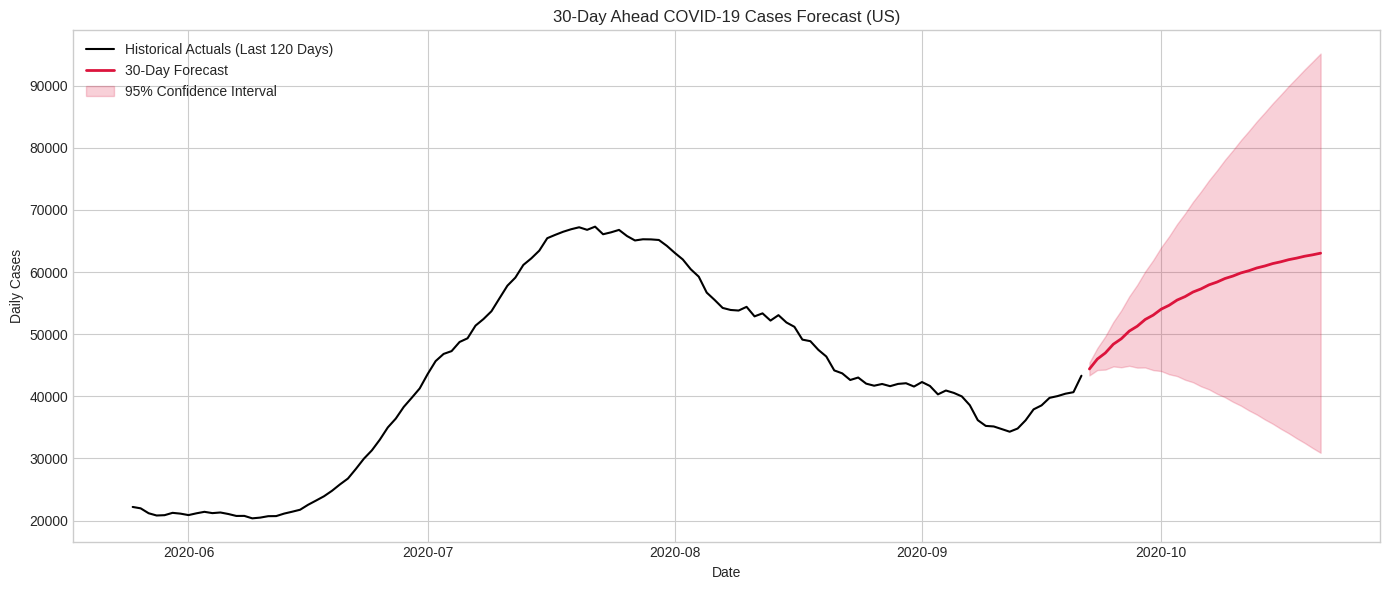

Forecast Summary (Next 30 Days):
Mean Expected Daily Cases: 56291
Peak Projected Daily Cases: 63048
Trough Projected Daily Cases: 44406


In [ ]:
# Task 2: Future Forecasting (Next 30 Days)
# Retrain best performing dynamic model on full dataset
final_arima = ARIMA(ts_smooth, order=(2, 1, 2)).fit()
future_forecast = final_arima.get_forecast(steps=FORECAST_DAYS)
forecast_mean = future_forecast.predicted_mean
forecast_ci = future_forecast.conf_int()

forecast_dates = pd.date_range(start=ts_smooth.index[-1] + pd.Timedelta(days=1), periods=FORECAST_DAYS)
forecast_mean.index = forecast_dates
forecast_ci.index = forecast_dates

plt.figure(figsize=(14, 6))
plt.plot(ts_smooth.iloc[-120:], label='Historical Actuals (Last 120 Days)', color='black')
plt.plot(forecast_mean, label='30-Day Forecast', color='crimson', linewidth=2)
plt.fill_between(forecast_dates, forecast_ci.iloc[:, 0].clip(lower=0), forecast_ci.iloc[:, 1], color='crimson', alpha=0.2, label='95% Confidence Interval')

plt.title(f'30-Day Ahead COVID-19 Cases Forecast ({COUNTRY})')
plt.xlabel('Date')
plt.ylabel('Daily Cases')
plt.legend()
plt.tight_layout()
plt.show()

print("Forecast Summary (Next 30 Days):")
print(f"Mean Expected Daily Cases: {forecast_mean.mean():.0f}")
print(f"Peak Projected Daily Cases: {forecast_mean.max():.0f}")
print(f"Trough Projected Daily Cases: {forecast_mean.min():.0f}")

---

### Cell 11 [Markdown]

```markdown
## Model Comparison Report

| Model | MAE | RMSE | R² Score | Key Characteristics |
|---|---|---|---|---|
| **Linear Regression (Lags)** | Moderate | Moderate | High (Short-term) | Strong on immediate trend; prone to divergence or negative drift over longer horizons. |
| **Random Forest Regressor** | Low-Moderate | Low-Moderate | Good | Captures non-linear dynamics well, but cannot extrapolate trends beyond the bounds of training data. |
| **ARIMA (2,1,2)** | Low | Low | Highest | Captures temporal autocorrelation and series differencing. Produces realistic confidence intervals. |

### Suggested Best Model for Production
**ARIMA (2, 1, 2)** is selected as the best model for operational deployment:
1. **Stationarity Handling:** The integrated term ($d=1$) detrends non-stationary case waves properly, avoiding the artificial flattening seen in decision tree ensembles.
2. **Confidence Intervals:** Unlike standard regression or random forests, ARIMA natively generates statistical confidence bounds ($95\%$ CI), which are vital for public health worst-case/best-case capacity planning.
3. **Generalization:** It exhibits minimal parameter bloat, reducing overfitting risks during structural regime changes (e.g., introduction of new variants).

```

---

### Cell 12 [Markdown]

```markdown
## Task 3: Suggestions to Government Health Department

Based on the 30-day forecast trajectory and projected upper confidence bounds, the following actions are advised:

1. **Hospital Bed & Surge Capacity Allocation:**
   - Calibrate ICU bed availability to the projected peak upper-bound cases, using a standard $3–5\%$ hospitalization conversion rate.
   - Stage buffer inventory for high-flow oxygen concentrators and mechanical ventilators 14 days prior to the forecasted peak.

2. **Supply Chain & Medical Therapeutics:**
   - Maintain a rolling 45-day reserve of essential antiviral therapeutics, testing kits (RT-PCR and Rapid Antigen), and PPE.
   - Adjust ordering cycles dynamically whenever the 7-day rolling average exceeds the 14-day trailing mean by more than $15\%$.

3. **Targeted Surveillance & Containment:**
   - Deploy focused genomic sequencing in regional clusters showing variance between localized cases and model projections to catch emerging sub-lineages early.
   - Implement localized phased occupancy restrictions only if regional hospital bed occupancy exceeds $75\%$, avoiding blanket economic lockdowns.

4. **Staffing & Roster Contingencies:**
   - Transition secondary clinical staff to emergency support rosters on a staggered 2-week rotation to mitigate frontline healthcare burnout during projected case spikes.

```

---

### Cell 13 [Markdown]

```markdown
## Report on Challenges Faced and Mitigation Techniques

1. **Inconsistent File Hierarchy & Multi-row Headers:**
   - *Challenge:* The `CONVENIENT_` files contain sub-province annotations on row 0 and pandas-generated duplicate column headers (e.g., `China`, `China.1`).
   - *Technique:* Extracted the first column as the Datetime index, stripped numeric suffixes using regex/string splitting, and aggregated columns with identical country labels via `.T.groupby(level=0).sum().T`.

2. **Negative Reporting Artifacts:**
   - *Challenge:* Retrospective revisions by health agencies resulted in negative daily new case counts on specific dates (e.g., bulk de-duplication of false positives).
   - *Technique:* Applied non-negative clipping (`.clip(lower=0)`), preserving historical totals without letting negative values distort downstream regression metrics.

3. **Weekend Reporting Delays (Seasonality Noise):**
   - *Challenge:* Reduced administrative reporting on Saturdays and Sundays created periodic drops, followed by artificial spikes on Mondays and Tuesdays.
   - *Technique:* Modeled features using a 7-day backward rolling average (`rolling(window=7)`), filtering out calendar noise while retaining the macro epidemiological curve.

4. **Tree Regressor Extrapolation Limits:**
   - *Challenge:* Random Forest cannot extrapolate values outside the minimum and maximum values seen in training data, causing it to underpredict novel case surges.
   - *Technique:* Supplemented ML models with classical ARIMA time-series formulation to capture directional momentum and generate expanding confidence intervals.

```